In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

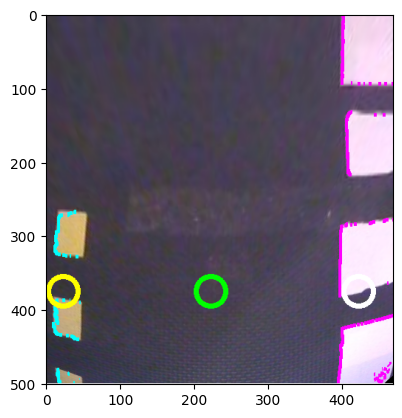

In [33]:
img = cv2.imread('test_parking.png')[:,:470]
#img = cv2.imread('test_duckies_2.png')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

plt.imshow(img)

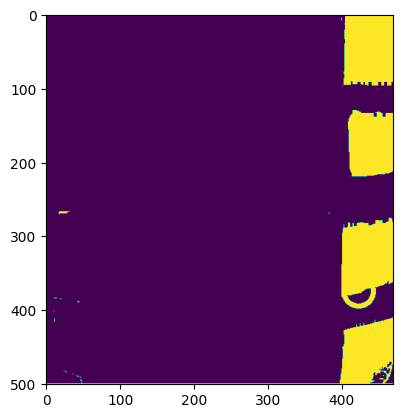

In [34]:
mask = cv2.inRange(hsv, 
                           (0,0, 150), 
                           (255,50,255))
plt.imshow(mask)

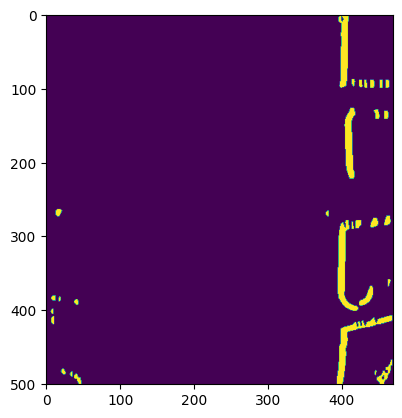

In [35]:
mask = cv2.GaussianBlur(mask, (0,0), 1.3, 1.3)
grad = cv2.Sobel(mask, cv2.CV_16S, 1, 0, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
_,th1 = cv2.threshold(grad,127,255,cv2.THRESH_BINARY)

plt.imshow(th1)

In [37]:


def detet_parking(th):
    idx = np.where(th != 0)
    y_prev = 0
    gap = 0
    for y in idx[0]:
        if y - y_prev > 10:
            gap += 1
        
        y_prev = y

    if gap >= 2:
        return True

    return False

detet_parking(th1)

True